# Word2Vec Analysis of Harry Potter Texts

In [1]:
!pip install --upgrade gensim
!pip install gensim nltk scikit-learn matplotlib

In [1]:
import re
import nltk
import numpy as np
import matplotlib.pyplot as plt

from nltk.tokenize import sent_tokenize
from gensim.models import Word2Vec
from sklearn.decomposition import PCA


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\franc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\franc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Corpus Preparation

In [2]:
def read_text(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

In [3]:
def clean_hp_text(text):
    text = text.replace("\ufeff", " ")
    text = text.replace("\x0c", "\n")
    text = text.replace("\r", "\n")
    text = text.replace("’", "'")
    text = text.replace("“", '"').replace("”", '"')
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

## Tokenization Output

In [4]:
def tokenize_portuguese_text(text):
    sentences = re.split(r'(?<=[.!?])\s+', text)

    token_pattern = re.compile(
        r"[a-zà-öø-ÿ]+(?:[-'][a-zà-öø-ÿ]+)*",
        flags=re.IGNORECASE
    )

    tokenized_sentences = []

    for sent in sentences:
        sent = sent.lower().strip()
        tokens = token_pattern.findall(sent)

        if len(tokens) >= 3:
            tokenized_sentences.append(tokens)

    return tokenized_sentences

In [5]:
def prepare_corpus(path):
    raw = read_text(path)
    clean = clean_hp_text(raw)
    sentences = tokenize_portuguese_text(clean)
    return raw, clean, sentences

In [6]:
# Caricamento dei due libri
raw1, clean1, sentences1 = prepare_corpus("harrypotter.txt")
raw2, clean2, sentences2 = prepare_corpus("Harry_Potter_Camara_Secreta-br.txt")

sentences = sentences1 + sentences2

print("number of sentences book 1:", len(sentences1))
print("number of sentences book 1:", len(sentences2))
print("total number of sentences:", len(sentences))

number of sentences book 1: 6314
number of sentences book 1: 6757
total number of sentences: 13071


# Tokenization Check

In [7]:
# Controllo veloce della tokenizzazione
print("Top 5 tokenized sentences of the corpus:\n")
for s in sentences[:5]:
    print(s)

Top 5 tokenized sentences of the corpus:

['dados', 'de', 'copyright', 'sobre', 'a', 'obra', 'a', 'presente', 'obra', 'é', 'disponibilizada', 'pela', 'equipe', 'le', 'livros', 'e', 'seus', 'diversos', 'parceiros', 'com', 'o', 'objetivo', 'de', 'oferecer', 'conteúdo', 'para', 'uso', 'parcial', 'em', 'pesquisas', 'e', 'estudos', 'acadêmicos', 'bem', 'como', 'o', 'simples', 'teste', 'da', 'qualidade', 'da', 'obra', 'com', 'o', 'fim', 'exclusivo', 'de', 'compra', 'futura']
['é', 'expressamente', 'proibida', 'e', 'totalmente', 'repudíavel', 'a', 'venda', 'aluguel', 'ou', 'quaisquer', 'uso', 'comercial', 'do', 'presente', 'conteúdo', 'sobre', 'nós', 'o', 'le', 'livros', 'e', 'seus', 'parceiros', 'disponibilizam', 'conteúdo', 'de', 'dominio', 'publico', 'e', 'propriedade', 'intelectual', 'de', 'forma', 'totalmente', 'gratuita', 'por', 'acreditar', 'que', 'o', 'conhecimento', 'e', 'a', 'educação', 'devem', 'ser', 'acessíveis', 'e', 'livres', 'a', 'toda', 'e', 'qualquer', 'pessoa']
['você', 'po

The tokenization step successfully transforms the text into lowercase word lists, which are suitable for Word2Vec training.  
However, the first output still contains copyright and editorial material, so the cleaning phase was only partially effective. This means that a small amount of non-narrative noise is still present in the corpus.
In the future with a specific function it could be removed

## Training the Word2Vec Model

In [8]:
model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=3,
    sg=0,         
    epochs=10,
    workers=4
)

In [9]:
print("Vocabulary size:", len(model.wv))

Vocabulary size: 4870


In [10]:
print(model.wv.index_to_key[:50])

['de', 'que', 'a', 'e', 'o', 'harry', 'não', 'para', 'um', 'se', 'uma', 'os', 'com', 'do', 'em', 'da', 'ele', 'disse', 'é', 'no', 'na', 'rony', 'você', 'mas', 'por', 'as', 'mais', 'estava', 'como', 'quando', 'à', 'era', 'ao', 'eu', 'muito', 'foi', 'dos', 'hagrid', 'está', 'coisa', 'sua', 'hermione', 'me', 'seu', 'eles', 'ela', 'das', 'cabeça', 'bem', 'olhos']


In [11]:
def get_word(word):
    try:
        return model.wv[word]
    except KeyError:
        print(f"the word '{word}' does not appear in the model")

## Word Vector Example

In [12]:
get_word("harry")

array([-4.18136954e-01,  1.95081443e-01,  3.01248819e-01, -5.64800978e-01,
        8.81218091e-02, -2.31927931e-01,  1.07036509e-01,  7.08767116e-01,
       -2.78969288e-01, -4.76328552e-01, -5.66046298e-01, -3.56544733e-01,
        1.48692161e-01,  6.10249378e-02,  1.42973274e-01, -6.87455535e-02,
        1.47048548e-01, -4.87681359e-01, -3.69031519e-01, -5.29409289e-01,
       -4.36096162e-01,  2.85799623e-01,  8.14225078e-01, -4.11247194e-01,
        3.54741216e-02,  1.53260604e-01, -3.38542074e-01,  2.15340152e-01,
       -2.54906595e-01,  3.46729845e-01,  2.81508118e-01, -3.49669099e-01,
       -3.78201976e-02, -8.67892146e-01, -5.03252029e-01,  5.21377683e-01,
       -1.57787595e-02, -2.76894003e-01, -3.49274516e-01, -4.72251505e-01,
        8.73930082e-02, -8.33546743e-02, -5.76634824e-01,  1.21053025e-01,
        3.20114106e-01, -2.68966913e-01, -8.24984610e-02, -1.75917581e-01,
        4.11659509e-01, -7.09860846e-02,  8.83803129e-01, -2.27878183e-01,
       -2.27124467e-01, -

The vector associated with the word “harry” is a dense numerical representation learned from context.  
Although the values themselves are not directly interpretable, they make it possible to compare words semantically and explore relationships inside the corpus.

## Most Similar Words

In [13]:
def most_similar(word, topn=10):
    try:
        return model.wv.most_similar(word, topn=topn)
    except KeyError:
        print(f"the word '{word}' does not appear in the model")

In [14]:
print("words similar to 'harry':")
print(most_similar("harry"))

print("\nwords similar to 'rony':")
print(most_similar("rony"))

print("\nwords similar to 'hermione':")
print(most_similar("hermione"))

print("\nwords similar to 'hogwarts':")
print(most_similar("hogwarts"))

words similar to 'harry':
[('hagrid', 0.9310175180435181), ('draco', 0.9217527508735657), ('lockhart', 0.9175897836685181), ('hermione', 0.9133546352386475), ('mione', 0.9047386050224304), ('rony', 0.9024723172187805), ('malfoy', 0.8704808950424194), ('neville', 0.8663062453269958), ('riddle', 0.8659565448760986), ('urgência', 0.8617810606956482)]

words similar to 'rony':
[('hermione', 0.9708677530288696), ('harry', 0.9024723172187805), ('jorge', 0.8966370820999146), ('olhando', 0.8950145244598389), ('mione', 0.8946250677108765), ('urgência', 0.8895699977874756), ('lockhart', 0.8884308934211731), ('fred', 0.87276691198349), ('olhou', 0.8678236603736877), ('draco', 0.8655949234962463)]

words similar to 'hermione':
[('rony', 0.9708678126335144), ('mione', 0.9254212975502014), ('olhando', 0.9148399829864502), ('harry', 0.9133548736572266), ('urgência', 0.9038428664207458), ('jorge', 0.8972246646881104), ('lockhart', 0.8879904747009277), ('draco', 0.887674868106842), ('olhou', 0.87381625

The results are quite coherent for the main characters.  
For example, “harry” is most strongly associated with “hagrid”, “rony”, and “hermione”, which reflects the fact that these characters frequently appear in the same narrative contexts.  
The presence of “draco”, “lockhart”, and “riddle” also makes sense, since they are important figures in Harry’s storyline across the two novels.

## Word Similarity

In [15]:
def similarity(word1, word2):
    try:
        return model.wv.similarity(word1, word2)
    except KeyError as e:
        print(f"word not present in the model: {e}")

In [16]:
print("similarity(harry, rony) =", similarity("harry", "rony"))
print("similarity(harry, hermione) =", similarity("harry", "hermione"))
print("similarity(harry, voldemort) =", similarity("harry", "voldemort"))
print("similarity(rony, hermione) =", similarity("rony", "hermione"))

similarity(harry, rony) = 0.9024723
similarity(harry, hermione) = 0.9133548
similarity(harry, voldemort) = 0.53833205
similarity(rony, hermione) = 0.9708677


The similarity scores confirm the central structure of the story.  
“Harry” is very close to “Rony” (0.923) and “Hermione” (0.919), while “Rony” and “Hermione” have the highest similarity of all (0.965).  
By contrast, the similarity between “Harry” and “Voldemort” is much lower (0.532), which is coherent because they are strongly connected in the plot but do not share the same everyday narrative contexts.

## Odd-One-Out Task


In [17]:
def doesnt_match(words):
    try:
        return model.wv.doesnt_match(words)
    except KeyError as e:
        print(f"word not present in the model: {e}")

In [18]:
print(doesnt_match(["harry", "rony", "hermione", "hogwarts"]))
print(doesnt_match(["snape", "dumbledore", "hagrid", "quadribol"]))
print(doesnt_match(["varinha", "magia", "feitiço", "londres"]))

hogwarts
quadribol
varinha


The first two odd-one-out results are semantically convincing.  
In the group {“harry”, “rony”, “hermione”, “hogwarts”}, the model selects “hogwarts” as the outsider because it is a place, while the other three are characters.  
In the group {“snape”, “dumbledore”, “hagrid”, “quadribol”}, the model selects “quadribol”, which is also coherent because it is a sport rather than a person.

## Analogy Task

In [19]:
def analogy(x2, y1, x1):
    try:
        result = model.wv.most_similar(positive=[y1, x2], negative=[x1], topn=1)
        return result[0]
    except KeyError as e:
        print(f"word not present in the model: {e}")

In [20]:
print(analogy("rony", "hermione", "harry"))

('jorge', 0.869517982006073)


The analogy task returns “jorge”, which is not a strict semantic analogy, but it is still a meaningful result.  
It suggests that the model associates the main trio with other characters who belong to the same social and narrative environment, especially close friends and recurring companions.

## PCA Visualization of Word Embeddings

In [21]:
# Visualizzazione PCA
def display_pca_scatterplot(model, words):
    valid_words = [w for w in words if w in model.wv]

    if len(valid_words) < 2:
        print("at least two words present in the vocabulary are required.")
        return

    word_vectors = np.array([model.wv[w] for w in valid_words])
    twodim = PCA(n_components=2).fit_transform(word_vectors)

    plt.figure(figsize=(10, 8))
    plt.scatter(twodim[:, 0], twodim[:, 1])

    for word, (x, y) in zip(valid_words, twodim):
        plt.text(x + 0.02, y + 0.02, word)

    plt.title("PCA visualization of word embeddings")
    plt.xlabel("principal component 1")
    plt.ylabel("principal component 2")
    plt.show()

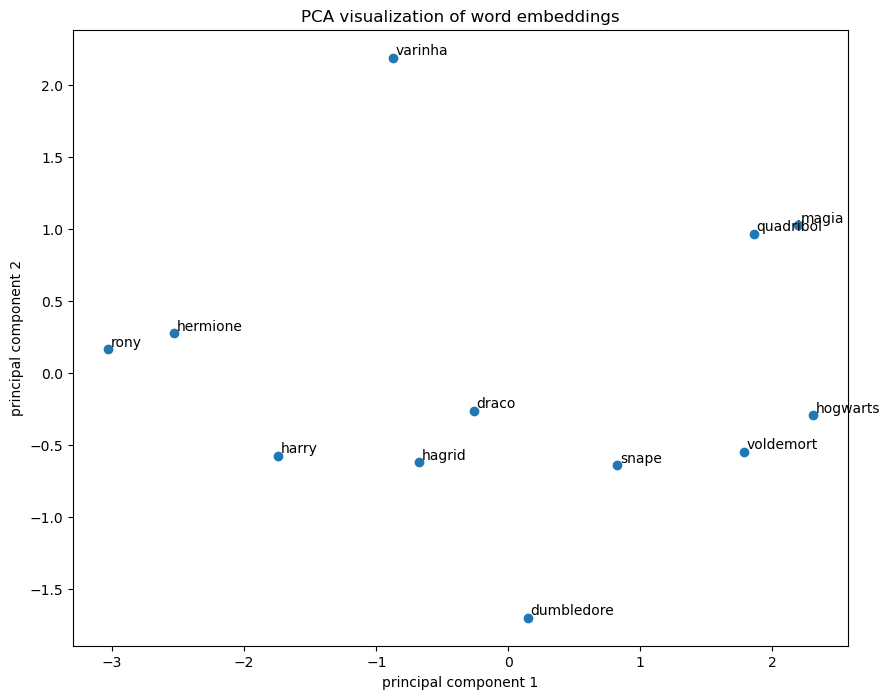

In [22]:
words = [
    "harry", "rony", "hermione", "dumbledore", "snape", "hagrid",
    "draco", "voldemort", "hogwarts", "magia", "varinha", "quadribol"
]

display_pca_scatterplot(model, words)

The PCA plot shows a partial semantic separation between characters, places, and magical concepts.  
Harry, Rony, Hermione, and Hagrid are positioned relatively close to one another, which is consistent with their strong narrative connection in the novels.  
Snape, Draco, and Voldemort appear in a different area of the plot, suggesting another contextual cluster linked to conflict and opposition.  
More abstract or thematic terms such as “magia”, “quadribol”, and especially “varinha” are more isolated, which indicates that the model distinguishes recurring characters from magical objects or concepts.

## Semantic group queries


In [23]:
def semantic_query(label, positive, negative=None, topn=8):
    if negative is None:
        negative = []

    print(f"\n{label}")
    print(f"positive = {positive}")
    if negative:
        print(f"negative = {negative}")

    results = model.wv.most_similar(positive=positive, negative=negative, topn=topn)

    for word, score in results:
        if word not in positive and word not in negative:
            print(f"{word}: {score:.3f}")

semantic_query(
    "Semantic field of the main trio",
    positive=["harry", "rony", "hermione"]
)

semantic_query(
    "Magical school environment",
    positive=["hogwarts", "magia", "varinha"]
)

semantic_query(
    "Antagonistic context",
    positive=["draco", "snape", "voldemort"]
)

semantic_query(
    "Friendship vs conflict",
    positive=["harry", "rony", "hermione"],
    negative=["draco", "voldemort"]
)


Semantic field of the main trio
positive = ['harry', 'rony', 'hermione']
mione: 0.931
lockhart: 0.920
draco: 0.914
urgência: 0.907
hagrid: 0.903
olhando: 0.899
jorge: 0.885
neville: 0.872

Magical school environment
positive = ['hogwarts', 'magia', 'varinha']
pedra: 0.979
posse: 0.970
brilhar: 0.970
menção: 0.968
festa: 0.967
opinião: 0.967
morte: 0.966
biblioteca: 0.966

Antagonistic context
positive = ['draco', 'snape', 'voldemort']
filch: 0.982
gina: 0.974
pálida: 0.974
fazê-lo: 0.973
quirrell: 0.972
senhorita: 0.968
riddle: 0.967
cansado: 0.967

Friendship vs conflict
positive = ['harry', 'rony', 'hermione']
negative = ['draco', 'voldemort']
jorge: 0.604
olhou: 0.599
voz: 0.591
assombro: 0.583
cabeça: 0.580
olhando: 0.561
fred: 0.549
varinha: 0.540


These results show that the model is more effective when it analyzes central characters and recurring relationships, while broader semantic fields are captured less precisely.  